In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("feature_engineered_crop_data.csv")

X = df.drop("Crop_Yield", axis=1)

y = df["Crop_Yield"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [4]:
model = joblib.load("best_model.pkl")

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Rainfall',
                                                   'Pesticides', 'Temperature',
                                                   'Rainfall_Temp_Index',
                                                   'Log_Pesticides']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Area', 'Item',
                                                   'Rainfall_Category',
                                                   'Temperature_Band',
                                                   'Pesticide_Category'])])),
                ('model',
                 RandomForestRegressor(n_estimators=50, n_jobs=-1,
                                       random_state=42))])


In [6]:
pred = model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print("MAE :", mae)

print("RMSE :", rmse)

print("R² :", r2)

MAE : 3499.41934065934
RMSE : 8710.5472548069
R² : 0.9846617292013019


In [8]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": pred

})

comparison.head()

,Actual,Predicted
0,155782.0,113483.94
1,15787.0,15701.14
2,72614.0,74614.14
3,30774.0,19688.92
4,28085.0,27849.66


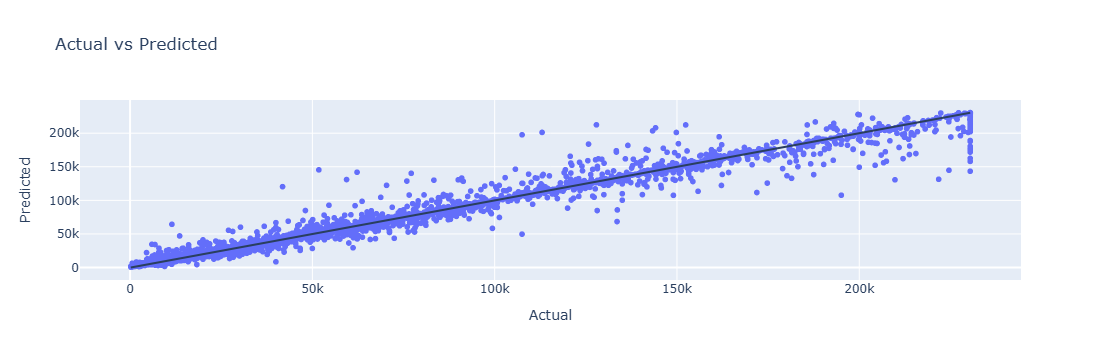

In [9]:
fig = px.scatter(

    comparison,

    x="Actual",

    y="Predicted",

    title="Actual vs Predicted"

)

fig.add_shape(

    type="line",

    x0=comparison["Actual"].min(),

    y0=comparison["Actual"].min(),

    x1=comparison["Actual"].max(),

    y1=comparison["Actual"].max()

)

fig.show()

In [11]:
comparison["Residual"] = (

    comparison["Actual"] -

    comparison["Predicted"]

)

comparison.head()

,Actual,Predicted,Residual
0,155782.0,113483.94,42298.06
1,15787.0,15701.14,85.86
2,72614.0,74614.14,-2000.14
3,30774.0,19688.92,11085.08
4,28085.0,27849.66,235.34


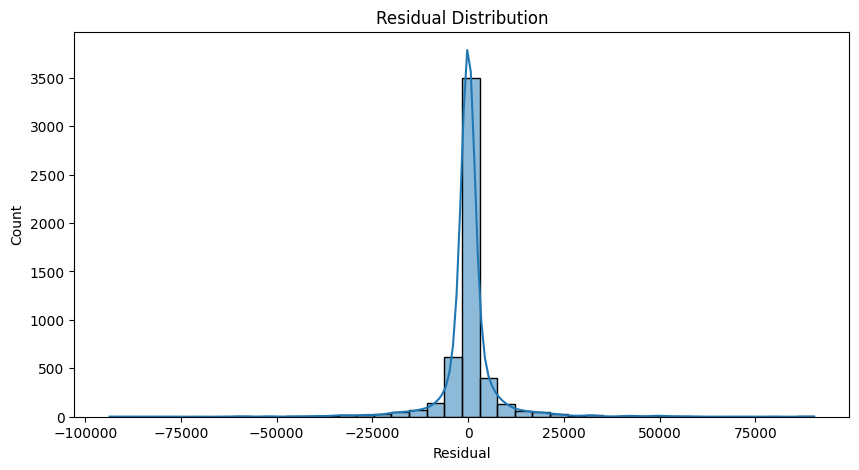

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(

    comparison["Residual"],

    bins=40,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

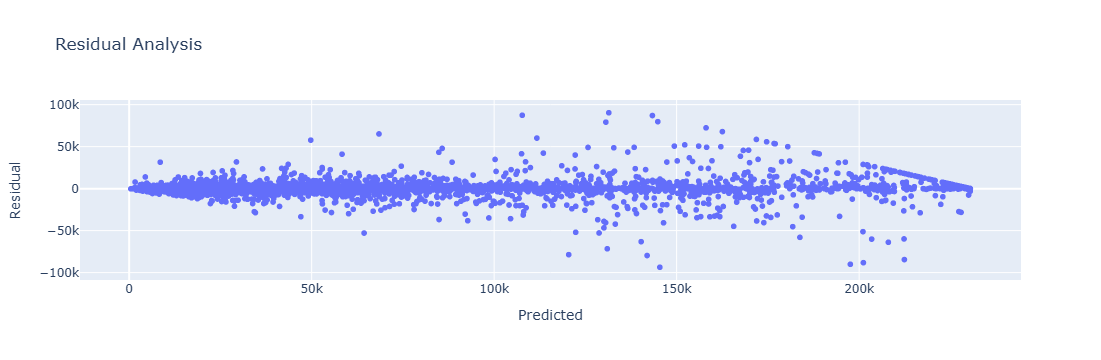

In [13]:
fig = px.scatter(

    comparison,

    x="Predicted",

    y="Residual",

    title="Residual Analysis"

)

fig.show()

In [14]:
comparison["Absolute Error"] = np.abs(

    comparison["Residual"]

)

comparison.describe()

,Actual,Predicted,Residual,Absolute Error
count,5187.000000,5187.000000,5187.000000,5187.000000
mean,73065.927511,72927.668317,138.259194,3499.419341
std,70339.472719,69480.757554,8710.289585,7977.466195
min,200.000000,448.620000,-93620.260000,0.000000
25%,20000.000000,20181.540000,-771.670000,82.420000
50%,40700.000000,40679.620000,0.000000,814.700000
75%,109127.500000,110037.240000,879.680000,3233.760000
max,230426.000000,230426.000000,90367.760000,93620.260000


In [15]:
comparison.to_csv(

    "prediction_results.csv",

    index=False

)

print("Prediction file saved.")

Prediction file saved.


In [16]:
try:

    feature_names = model.named_steps["preprocessor"].get_feature_names_out()

    importance = model.named_steps["model"].feature_importances_

    feature_df = pd.DataFrame({

        "Feature": feature_names,

        "Importance": importance

    })

    feature_df = feature_df.sort_values(

        "Importance",

        ascending=False

    )

    feature_df.head(20)

except:

    print("Feature importance is not available for this model.")

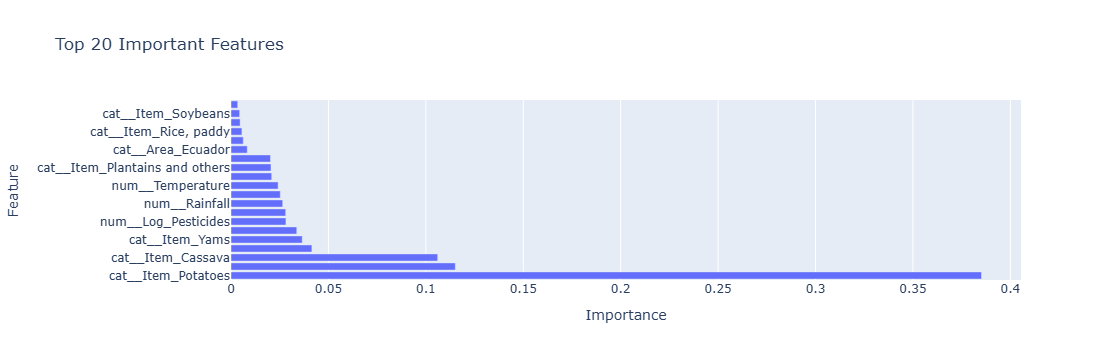

In [17]:
try:

    fig = px.bar(

        feature_df.head(20),

        x="Importance",

        y="Feature",

        orientation="h",

        title="Top 20 Important Features"

    )

    fig.show()

except:

    print("Skipped.")

In [18]:
print("="*60)

print("FINAL MODEL EVALUATION")

print("="*60)

print()

print(f"MAE : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")

print()

print("Model evaluation completed successfully.")

FINAL MODEL EVALUATION

MAE : 3499.42
RMSE : 8710.55
R² Score : 0.9847

Model evaluation completed successfully.
